# PrimateFace Tutorial: Data-Driven Discovery of Facial Actions

| GitHub | Paper | Website | Models |
|---|---|---|---|
| [Code](https://github.com/KordingLab/PrimateFace) | [Preprint](https://www.biorxiv.org/content/10.1101/2025.08.12.669927) | [Project](https://primateface.studio/) | [HuggingFace](https://huggingface.co/fparodi/primateface-models) |

This notebook discovers recurring facial actions (lip smacks, blinks, expressions) from video **without manual annotation**, using a MotionMapper-inspired pipeline:

1. Extract 68-point facial landmarks with PrimateFace
2. Compute kinematic features (mouth aperture, eye openness, etc.)
3. PCA on kinematics
4. Wavelet decomposition on PCs (time-frequency analysis)
5. UMAP embedding of wavelet amplitudes
6. Watershed segmentation to discover discrete action states
7. Ethogram visualization

**Reference**: Berman, G.J. et al. (2014). *Mapping the stereotyped behaviour of freely moving fruit flies.* J. R. Soc. Interface.

**Requirements**: PrimateFace + MMDetection/MMPose + GPU (recommended) + umap-learn + scikit-image

## 1. Setup

In [1]:
import sys
import warnings
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from notebook_utils import check_environment, setup_publication_style, save_fig
setup_publication_style()
env_info = check_environment(require_packages=["mmdet", "mmpose"])

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import cv2
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)

Publication plot style configured (Nature-style).


PrimateFace Environment
  Python:   3.11.11
  PyTorch:  2.1.2+cu118
  CUDA:     True
  Device:   cuda:0
  GPU:      NVIDIA GeForce RTX 4090 (25.8 GB)
  mmdet: 3.2.0 [OK]
  mmpose: 1.3.2 [OK]


## 2. Configuration

Update `VIDEO_PATH` to point to your primate video. Any video with visible facial movement works (vocalizations, social interactions, feeding).

In [ ]:
# --- UPDATE THIS ---
VIDEO_PATH = Path(r"path/to/your/video.mp4")

# Output directory for cached data and figures
OUTPUT_DIR = NOTEBOOK_DIR / "action_discovery_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Landmark cache file
CACHE_PATH = OUTPUT_DIR / "landmarks_cache.npz"

# Max frames to process (None = all)
MAX_FRAMES = None

# Video FPS (auto-detected if None)
FPS = None

assert VIDEO_PATH.exists(), f"Video not found: {VIDEO_PATH}"
print(f"Video: {VIDEO_PATH.name}")

## 3. Extract Landmarks

Run PrimateFace detection + 68-point pose estimation on every frame. Results are cached to disk.

In [3]:
from primateface import PrimateFace

if CACHE_PATH.exists():
    print(f"Loading cached landmarks from {CACHE_PATH}")
    data = np.load(CACHE_PATH)
    all_keypoints = data["keypoints"]  # (n_frames, 68, 3)
    fps = float(data["fps"])
    print(f"  {all_keypoints.shape[0]} frames, {fps:.1f} FPS")
else:
    print("Extracting landmarks (this may take a few minutes)...")
    pf = PrimateFace()

    cap = cv2.VideoCapture(str(VIDEO_PATH))
    fps = FPS or cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if MAX_FRAMES:
        total_frames = min(total_frames, MAX_FRAMES)
    print(f"  {total_frames} frames at {fps:.1f} FPS")

    keypoints_list = []
    for i in tqdm(range(total_frames)):
        ret, frame = cap.read()
        if not ret:
            break
        faces = pf.analyze(frame, det_threshold=0.3)
        if faces:
            # Take highest-confidence face
            keypoints_list.append(faces[0].keypoints)
        else:
            # No face detected — fill with NaN
            keypoints_list.append(np.full((68, 3), np.nan, dtype=np.float32))
    cap.release()

    all_keypoints = np.stack(keypoints_list)  # (n_frames, 68, 3)
    np.savez(CACHE_PATH, keypoints=all_keypoints, fps=fps)
    print(f"  Cached to {CACHE_PATH}")

n_frames = all_keypoints.shape[0]
print(f"\nTotal: {n_frames} frames ({n_frames / fps:.1f} seconds)")

Extracting landmarks (this may take a few minutes)...


Loads checkpoint by local backend from path: C:\Users\Felipe Parodi\.cache\huggingface\hub\models--fparodi--primateface-models\snapshots\4fade59531e3c11b77eacf26d741ef6746e09598\detection\cascade_rcnn_r101_fpn.pth


Loads checkpoint by local backend from path: C:\Users\Felipe Parodi\.cache\huggingface\hub\models--fparodi--primateface-models\snapshots\4fade59531e3c11b77eacf26d741ef6746e09598\pose\hrnetv2_w18_dark_68kpt.pth
Pose model loaded. Running detection + pose estimation.
  286 frames at 30.0 FPS


  0%|          | 0/286 [00:00<?, ?it/s]

  Cached to A:\NonEnclosureProjects\inprep\PrimateFace\primateface_oss\PrimateFace_os\demos\notebooks\action_discovery_output\landmarks_cache.npz

Total: 286 frames (9.5 seconds)


## 4. Compute Kinematic Time Series

Convert raw landmarks into interpretable features using PrimateFace's `analysis` module.

Timeseries shape: (286, 16)
Features: ['mouth_aperture', 'mouth_width', 'mouth_aspect_ratio', 'right_eye_aperture', 'left_eye_aperture', 'right_brow_height', 'left_brow_height', 'face_height', 'face_width', 'face_aspect_ratio', 'jaw_width', 'nose_length', 'eye_to_mouth', 'interocular_distance']


Figure saved: A:\NonEnclosureProjects\inprep\PrimateFace\primateface_oss\PrimateFace_os\demos\notebooks\action_discovery_output\raw_kinematics (.png/.svg/.pdf)


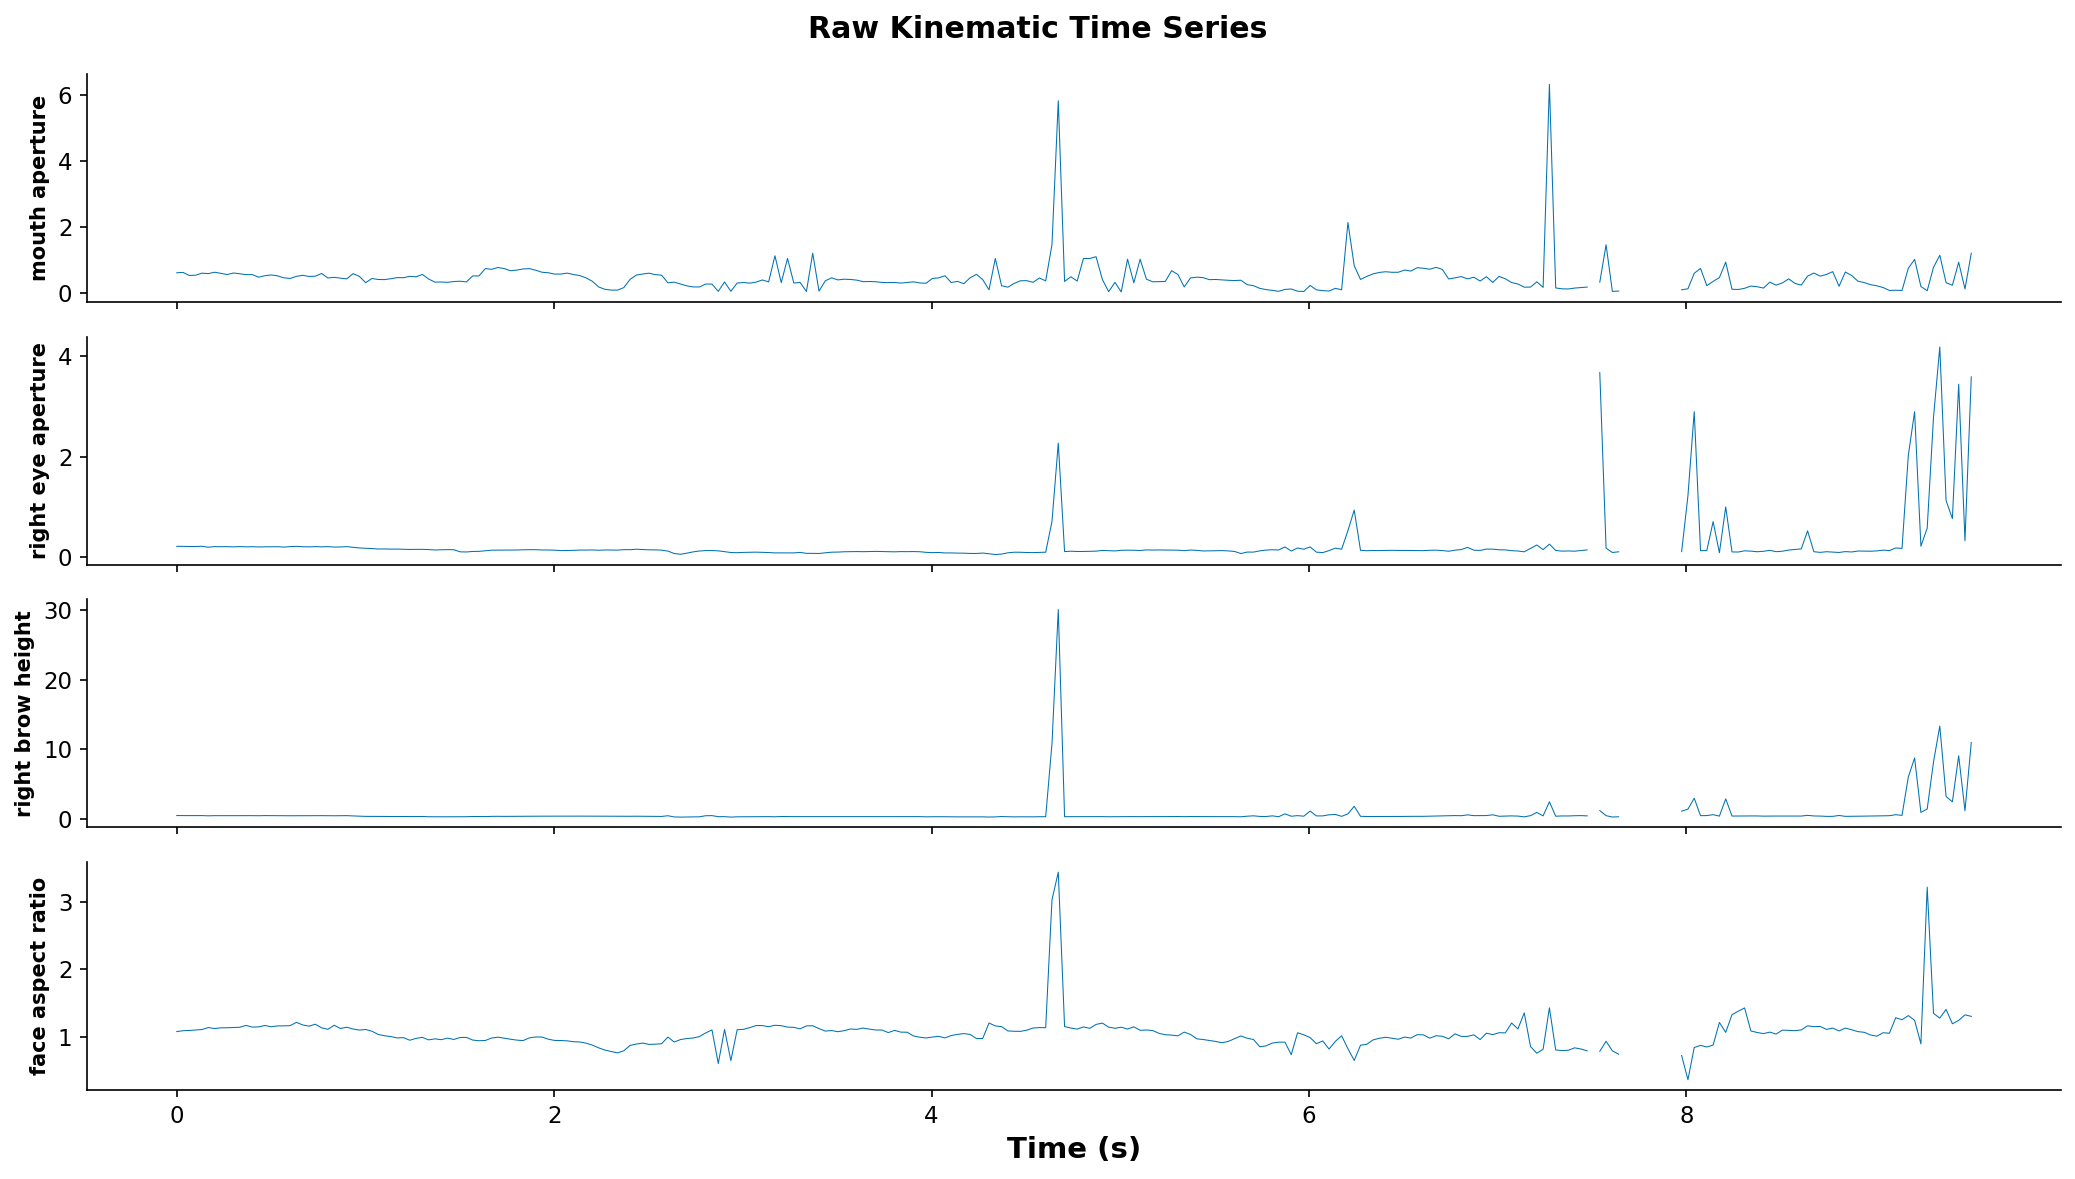

In [4]:
from analysis.kinematics import extract_timeseries

# Extract all kinematic features
ts = extract_timeseries(all_keypoints, fps=fps)
print(f"Timeseries shape: {ts.shape}")
print(f"Features: {[c for c in ts.columns if c not in ('frame', 'time_s')]}")

# Drop frame/time columns for analysis
feature_cols = [c for c in ts.columns if c not in ("frame", "time_s")]
X_raw = ts[feature_cols].values  # (n_frames, n_features)

# Handle NaN frames (no detection) via interpolation
from scipy.interpolate import interp1d
for col_idx in range(X_raw.shape[1]):
    signal = X_raw[:, col_idx]
    valid = ~np.isnan(signal)
    if valid.sum() > 2 and (~valid).any():
        f_interp = interp1d(np.where(valid)[0], signal[valid],
                            kind="linear", fill_value="extrapolate")
        X_raw[:, col_idx] = f_interp(np.arange(len(signal)))

# Plot raw time series
fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
time = ts["time_s"].values
for ax, feat in zip(axes, ["mouth_aperture", "right_eye_aperture", "right_brow_height", "face_aspect_ratio"]):
    ax.plot(time, ts[feat].values, linewidth=0.5)
    ax.set_ylabel(feat.replace("_", " "), fontsize=10)
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Raw Kinematic Time Series", fontweight="bold")
plt.tight_layout()
save_fig(fig, "raw_kinematics", str(OUTPUT_DIR))
plt.show()

## 5. PCA on Kinematics

Reduce the 14 kinematic features to their principal components.

Explained variance: [0.68621686 0.13639064 0.0701252  0.04950101 0.02493701 0.01438955]
Cumulative: [0.68621686 0.8226075  0.89273269 0.9422337  0.96717071 0.98156026]


Figure saved: A:\NonEnclosureProjects\inprep\PrimateFace\primateface_oss\PrimateFace_os\demos\notebooks\action_discovery_output\pca_kinematics (.png/.svg/.pdf)


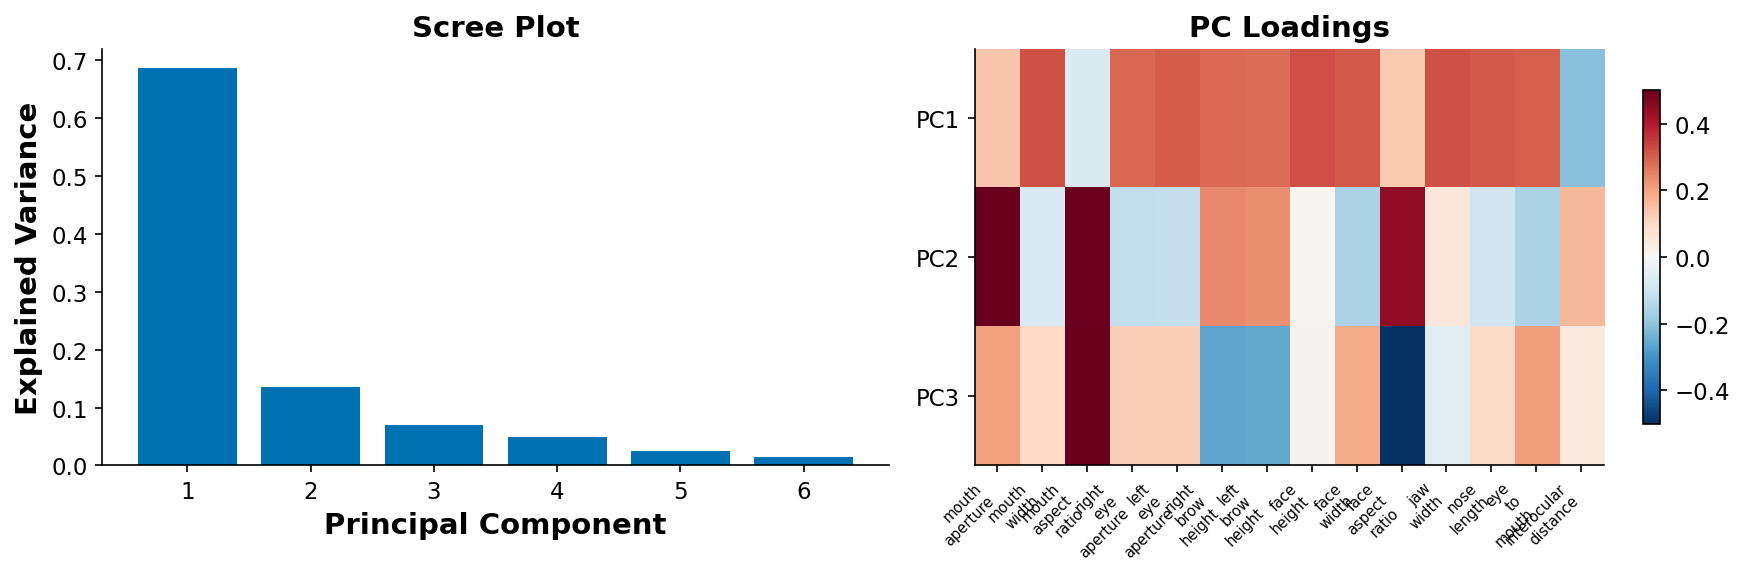

In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Z-score normalize
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_raw)

# PCA
n_pcs = min(6, X_norm.shape[1])
pca = PCA(n_components=n_pcs)
X_pca = pca.fit_transform(X_norm)  # (n_frames, n_pcs)

print(f"Explained variance: {pca.explained_variance_ratio_}")
print(f"Cumulative: {pca.explained_variance_ratio_.cumsum()}")

# Plot explained variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(range(1, n_pcs + 1), pca.explained_variance_ratio_, color="#0072B2")
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance")
ax1.set_title("Scree Plot")

# PC loadings
loadings = pca.components_[:3]  # top 3
im = ax2.imshow(loadings, aspect="auto", cmap="RdBu_r", vmin=-0.5, vmax=0.5)
ax2.set_yticks(range(3))
ax2.set_yticklabels([f"PC{i+1}" for i in range(3)])
ax2.set_xticks(range(len(feature_cols)))
ax2.set_xticklabels([c.replace("_", "\n") for c in feature_cols], rotation=45, ha="right", fontsize=7)
ax2.set_title("PC Loadings")
plt.colorbar(im, ax=ax2, shrink=0.8)

plt.tight_layout()
save_fig(fig, "pca_kinematics", str(OUTPUT_DIR))
plt.show()

## 6. Wavelet Decomposition

Apply continuous wavelet transform (Morlet) to each PC to capture time-frequency structure. This reveals oscillatory facial actions at different speeds.

Wavelet feature matrix: (286, 150)


Figure saved: A:\NonEnclosureProjects\inprep\PrimateFace\primateface_oss\PrimateFace_os\demos\notebooks\action_discovery_output\scalogram_pc1 (.png/.svg/.pdf)


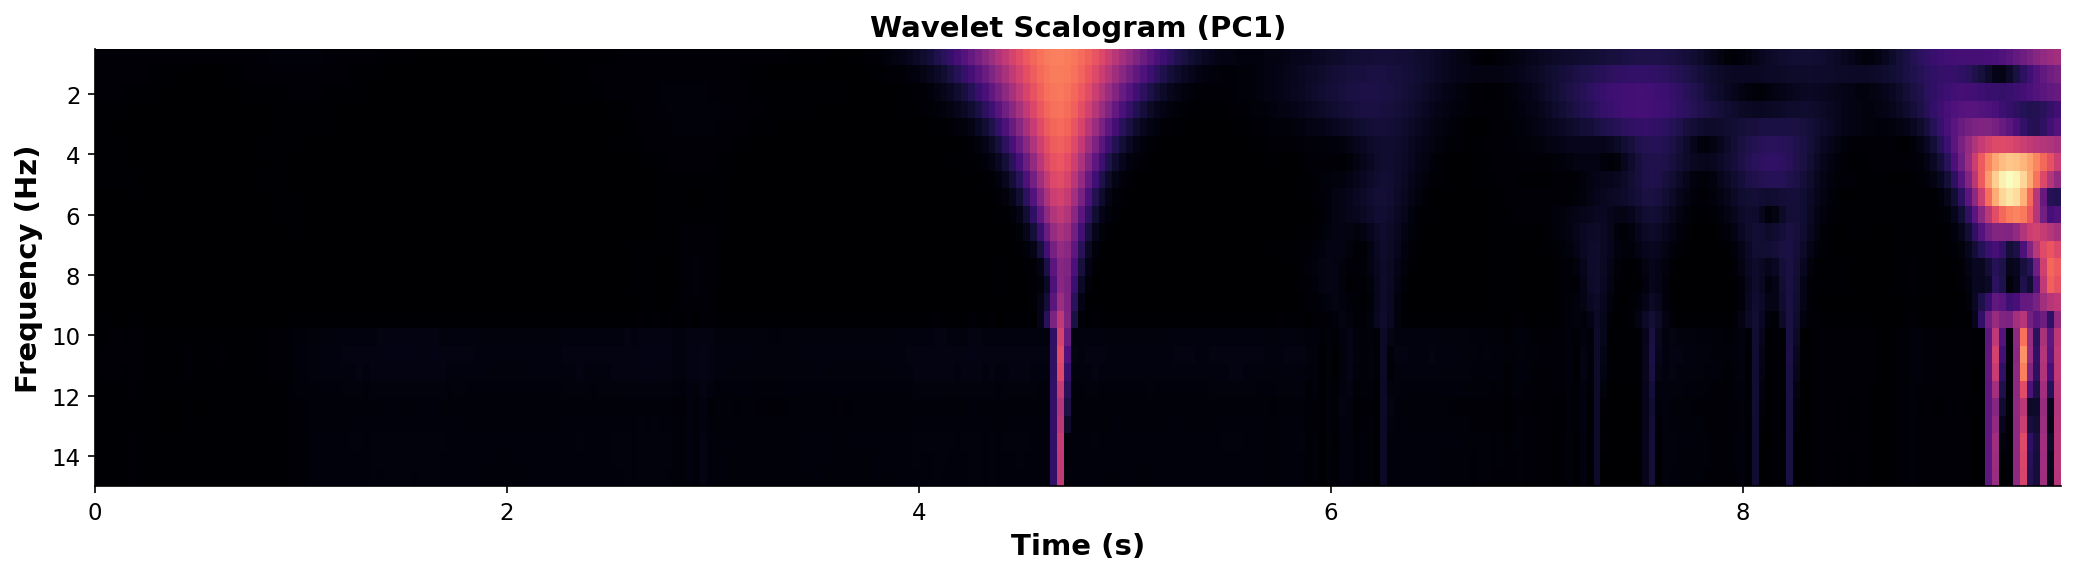

In [6]:
from scipy.signal import fftconvolve

def morlet_cwt(signal, scales, w=5.0):
    """Continuous wavelet transform with Morlet wavelet."""
    n = len(signal)
    result = np.zeros((len(scales), n), dtype=np.complex128)
    for i, s in enumerate(scales):
        M = min(10 * int(s), n)
        if M % 2 == 0:
            M += 1
        t = np.arange(-M // 2, M // 2 + 1) / s
        wavelet = np.exp(1j * w * t) * np.exp(-0.5 * t**2) * (np.pi ** -0.25)
        result[i] = fftconvolve(signal, wavelet[::-1], mode="same")
    return result

# Frequency range: 0.5 to 15 Hz
freqs = np.logspace(np.log10(0.5), np.log10(min(15, fps / 2)), 25)
scales = fps / (2 * np.pi * freqs)  # Convert Hz to CWT scales

# Compute wavelet transform for each PC
wavelet_features = []
for pc_idx in range(n_pcs):
    coeffs = morlet_cwt(X_pca[:, pc_idx], scales)
    wavelet_features.append(np.abs(coeffs).T)  # (n_frames, n_scales)

# Concatenate: (n_frames, n_scales * n_pcs)
W = np.concatenate(wavelet_features, axis=1)
print(f"Wavelet feature matrix: {W.shape}")

# Normalize amplitudes per scale
W_norm = W / (W.mean(axis=0, keepdims=True) + 1e-8)

# Plot scalogram for PC1
fig, ax = plt.subplots(figsize=(14, 4))
extent = [0, n_frames / fps, freqs[-1], freqs[0]]
ax.imshow(np.abs(morlet_cwt(X_pca[:, 0], scales)),
          aspect="auto", extent=extent, cmap="magma")
ax.set_ylabel("Frequency (Hz)")
ax.set_xlabel("Time (s)")
ax.set_title("Wavelet Scalogram (PC1)")
plt.tight_layout()
save_fig(fig, "scalogram_pc1", str(OUTPUT_DIR))
plt.show()

## 7. UMAP Embedding

Embed the wavelet amplitude matrix into 2D. Each point is one video frame; nearby points have similar facial dynamics.

C:\ProgramData\miniconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding: (286, 2)


Figure saved: A:\NonEnclosureProjects\inprep\PrimateFace\primateface_oss\PrimateFace_os\demos\notebooks\action_discovery_output\umap_by_time (.png/.svg/.pdf)


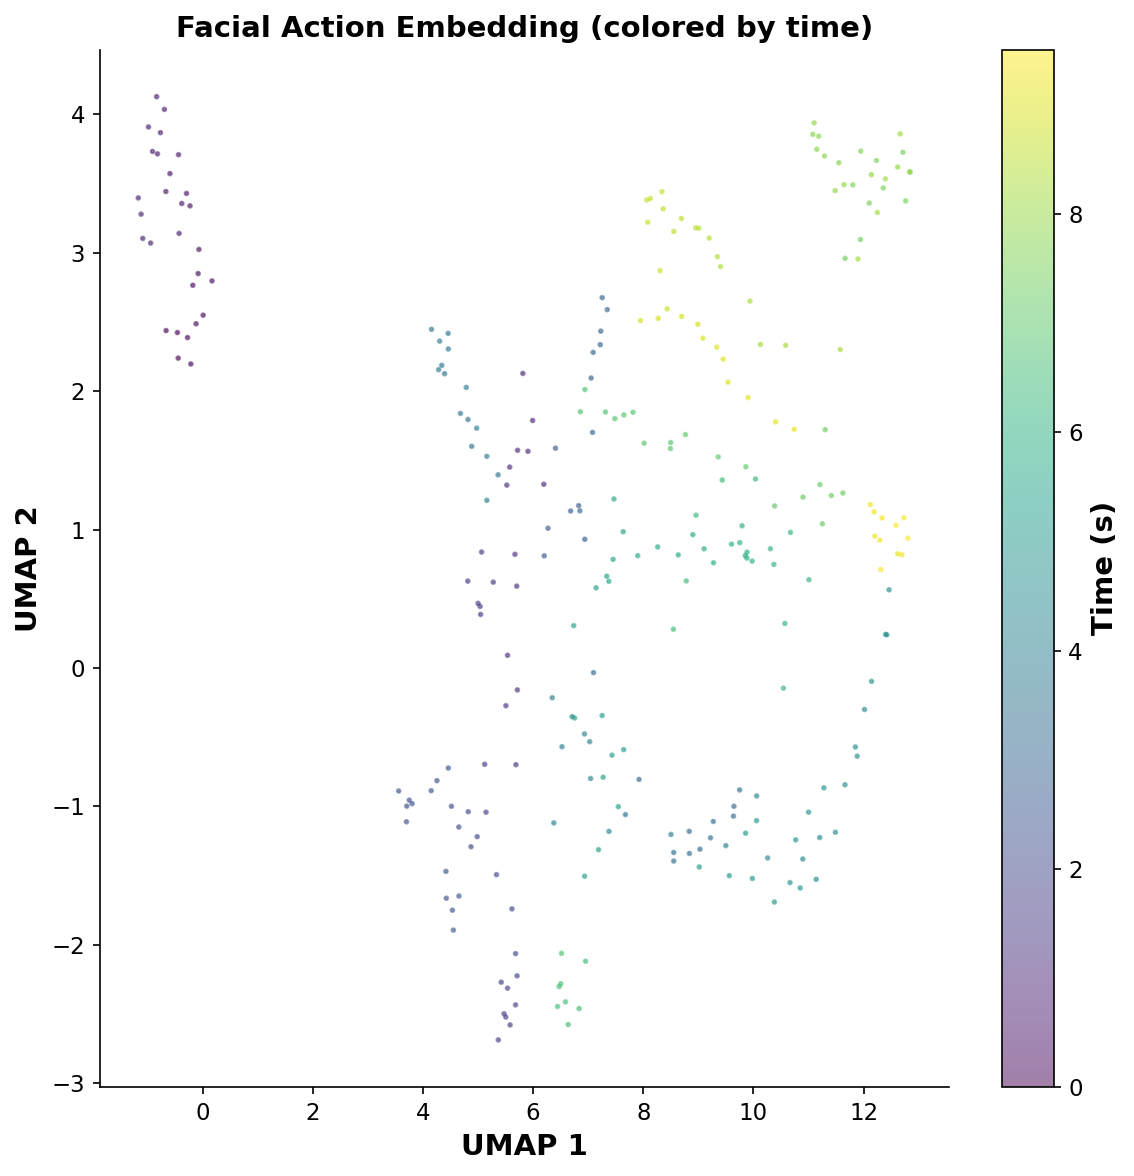

In [7]:
import umap

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.3, random_state=42)
embedding = reducer.fit_transform(W_norm)
print(f"UMAP embedding: {embedding.shape}")

# Plot colored by time
fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(embedding[:, 0], embedding[:, 1],
                c=np.arange(n_frames) / fps, cmap="viridis",
                s=3, alpha=0.5, rasterized=True)
plt.colorbar(sc, ax=ax, label="Time (s)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("Facial Action Embedding (colored by time)")
plt.tight_layout()
save_fig(fig, "umap_by_time", str(OUTPUT_DIR))
plt.show()

## 8. Watershed Segmentation

Estimate the density of the UMAP embedding and apply watershed segmentation to discover discrete action states.

Discovered 3 action states


C:\Users\Felipe Parodi\AppData\Local\Temp\ipykernel_48168\576295276.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab10", max(n_clusters, 2))


Figure saved: A:\NonEnclosureProjects\inprep\PrimateFace\primateface_oss\PrimateFace_os\demos\notebooks\action_discovery_output\watershed_clusters (.png/.svg/.pdf)


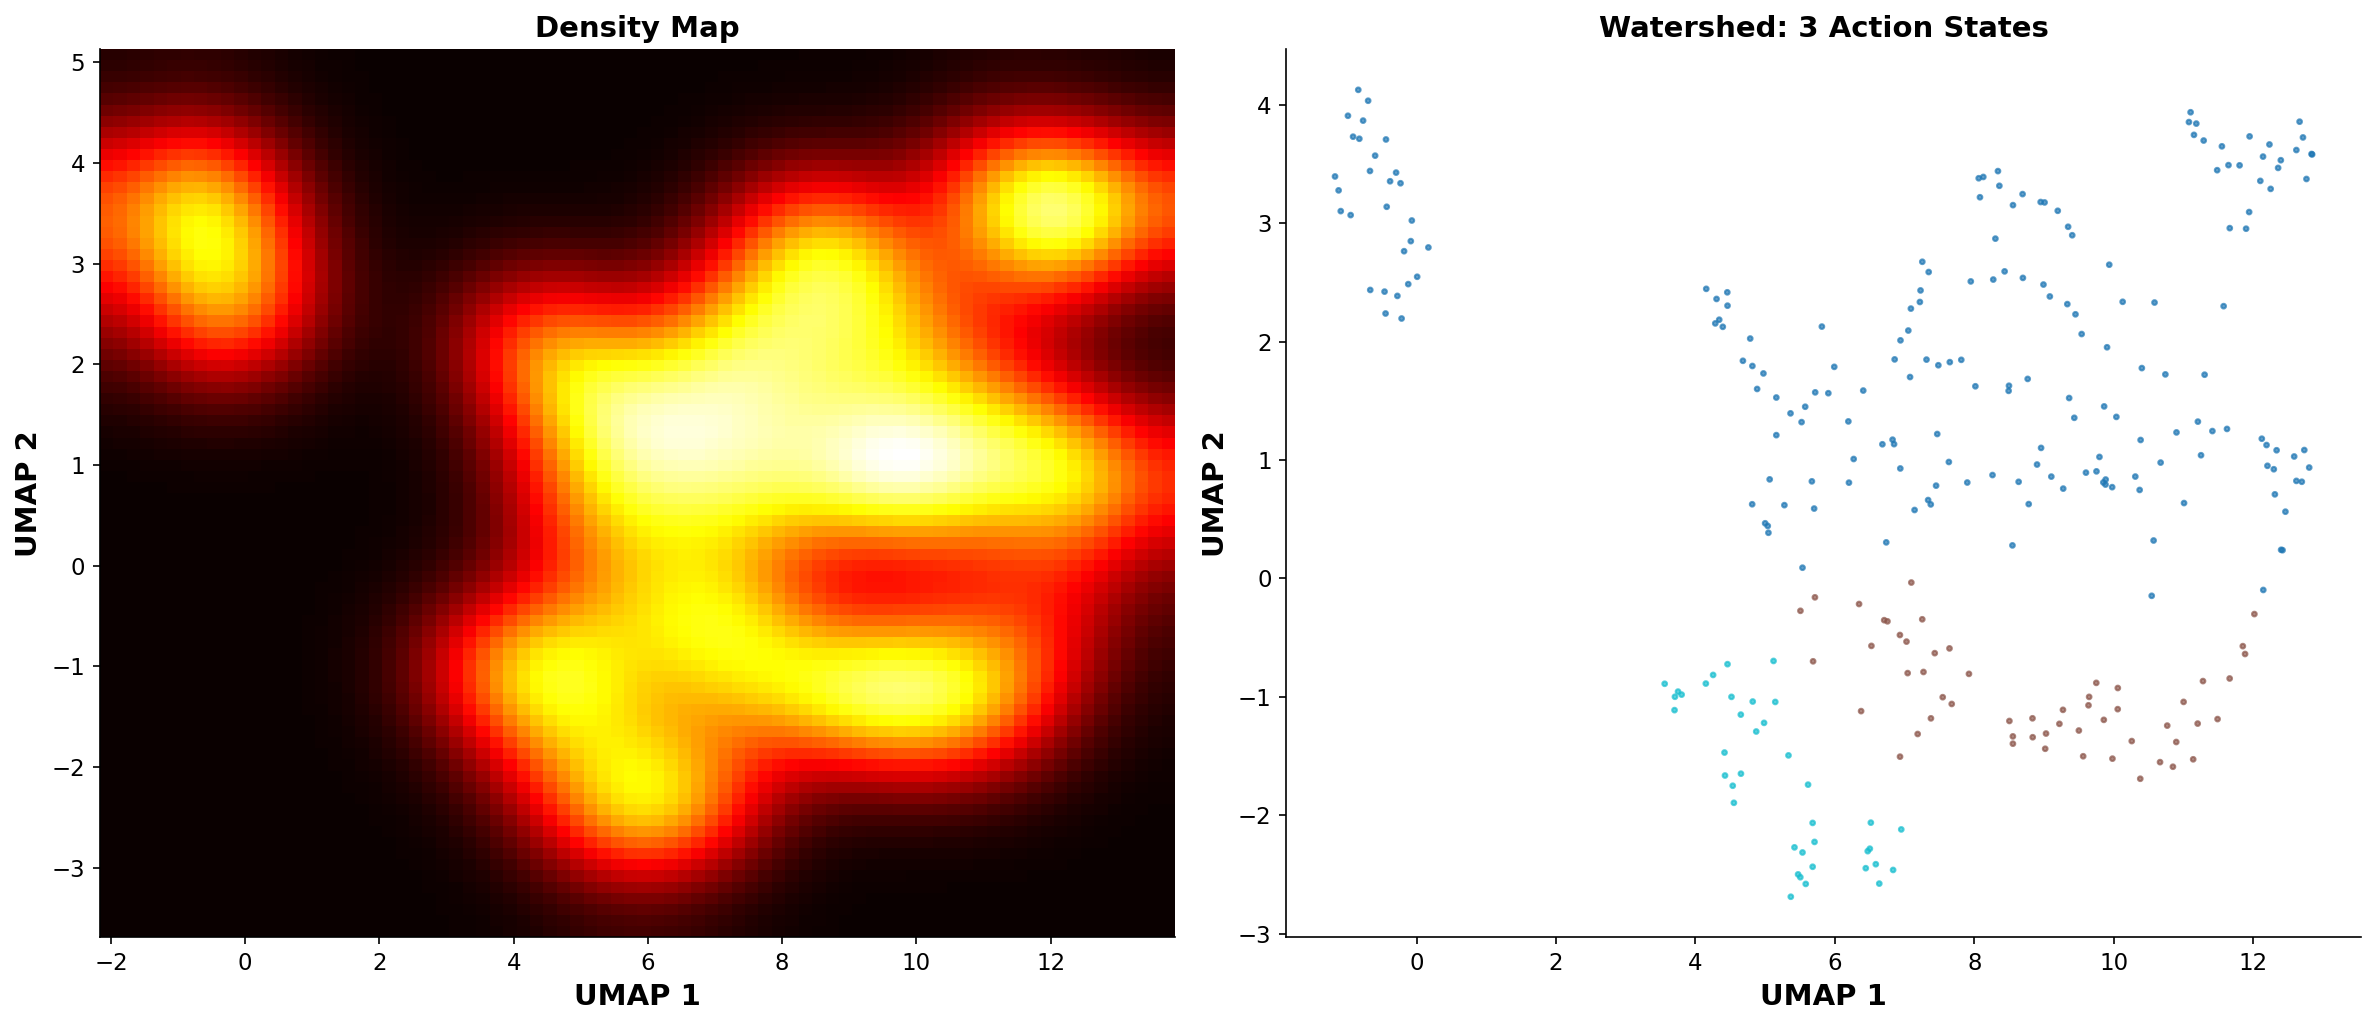

In [8]:
from scipy.ndimage import gaussian_filter
from skimage.segmentation import watershed
from skimage.feature import peak_local_max

# Compute 2D histogram (density)
grid_size = 80
x_range = (embedding[:, 0].min() - 1, embedding[:, 0].max() + 1)
y_range = (embedding[:, 1].min() - 1, embedding[:, 1].max() + 1)

density, xedges, yedges = np.histogram2d(
    embedding[:, 0], embedding[:, 1],
    bins=grid_size, range=[x_range, y_range]
)
density = gaussian_filter(density, sigma=5)

# Find density peaks and run watershed
coords = peak_local_max(density, min_distance=15, threshold_rel=0.1, exclude_border=True)
markers = np.zeros_like(density, dtype=int)
for i, (r, c) in enumerate(coords):
    markers[r, c] = i + 1

labels_grid = watershed(-density, markers, mask=density > density.max() * 0.05)
n_clusters = labels_grid.max()
print(f"Discovered {n_clusters} action states")

# Assign each frame to a cluster
x_bins = np.digitize(embedding[:, 0], xedges[:-1]) - 1
y_bins = np.digitize(embedding[:, 1], yedges[:-1]) - 1
x_bins = np.clip(x_bins, 0, grid_size - 1)
y_bins = np.clip(y_bins, 0, grid_size - 1)
frame_labels = labels_grid[x_bins, y_bins]

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Density map
ax1.imshow(density.T, origin="lower", cmap="hot",
           extent=[x_range[0], x_range[1], y_range[0], y_range[1]], aspect="auto")
ax1.set_xlabel("UMAP 1")
ax1.set_ylabel("UMAP 2")
ax1.set_title("Density Map")

# Cluster map
cmap = plt.cm.get_cmap("tab10", max(n_clusters, 2))
ax2.scatter(embedding[:, 0], embedding[:, 1],
            c=frame_labels, cmap=cmap, s=5, alpha=0.7, rasterized=True)
ax2.set_xlabel("UMAP 1")
ax2.set_ylabel("UMAP 2")
ax2.set_title(f"Watershed: {n_clusters} Action States")

plt.tight_layout()
save_fig(fig, "watershed_clusters", str(OUTPUT_DIR))
plt.show()

## 9. Ethogram

Visualize the discovered action state sequence over time.

C:\Users\Felipe Parodi\AppData\Local\Temp\ipykernel_48168\4123978436.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab10", max(n_clusters, 2))


Figure saved: A:\NonEnclosureProjects\inprep\PrimateFace\primateface_oss\PrimateFace_os\demos\notebooks\action_discovery_output\ethogram (.png/.svg/.pdf)


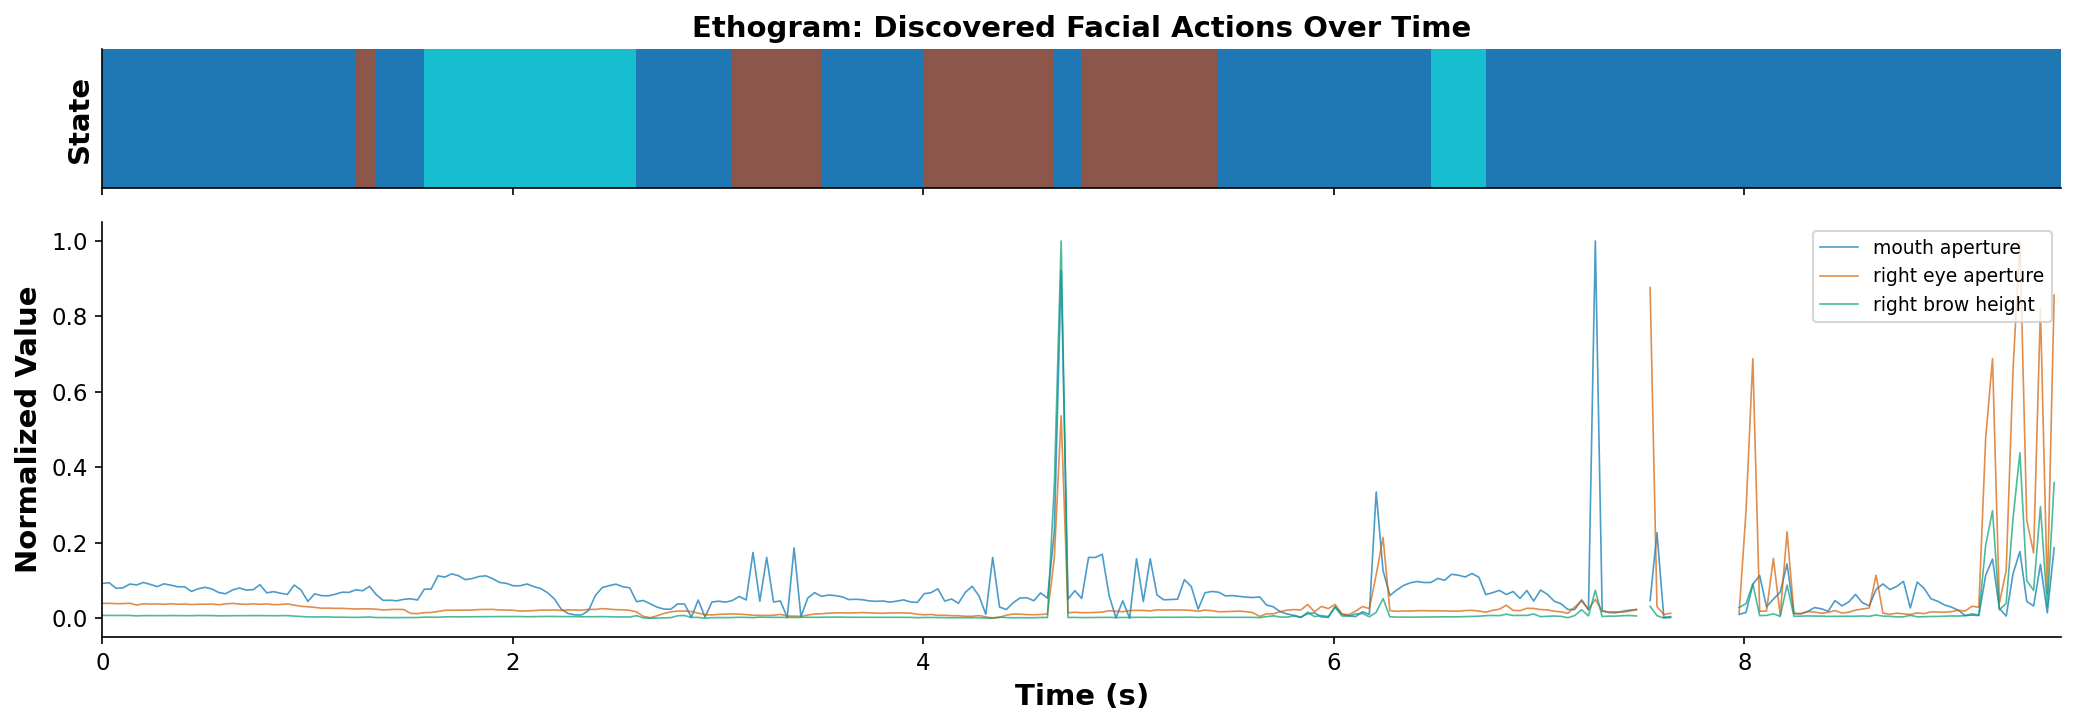

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True,
                                gridspec_kw={"height_ratios": [1, 3]})

# Ethogram (state bar)
cmap = plt.cm.get_cmap("tab10", max(n_clusters, 2))
ax1.imshow(frame_labels[np.newaxis, :], aspect="auto",
           cmap=cmap, extent=[0, n_frames / fps, 0, 1],
           interpolation="nearest")
ax1.set_yticks([])
ax1.set_ylabel("State")
ax1.set_title("Ethogram: Discovered Facial Actions Over Time")

# Overlay kinematic features
for feat, color in zip(["mouth_aperture", "right_eye_aperture", "right_brow_height"],
                       ["#0072B2", "#D55E00", "#009E73"]):
    vals = ts[feat].values
    vals_norm = (vals - np.nanmin(vals)) / (np.nanmax(vals) - np.nanmin(vals) + 1e-8)
    ax2.plot(time, vals_norm, linewidth=0.8, alpha=0.7, label=feat.replace("_", " "), color=color)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Normalized Value")
ax2.legend(loc="upper right", fontsize=9)

plt.tight_layout()
save_fig(fig, "ethogram", str(OUTPUT_DIR))
plt.show()

## 10. Cluster Profiles

What kinematic signature defines each discovered action state?

Figure saved: A:\NonEnclosureProjects\inprep\PrimateFace\primateface_oss\PrimateFace_os\demos\notebooks\action_discovery_output\cluster_profiles (.png/.svg/.pdf)


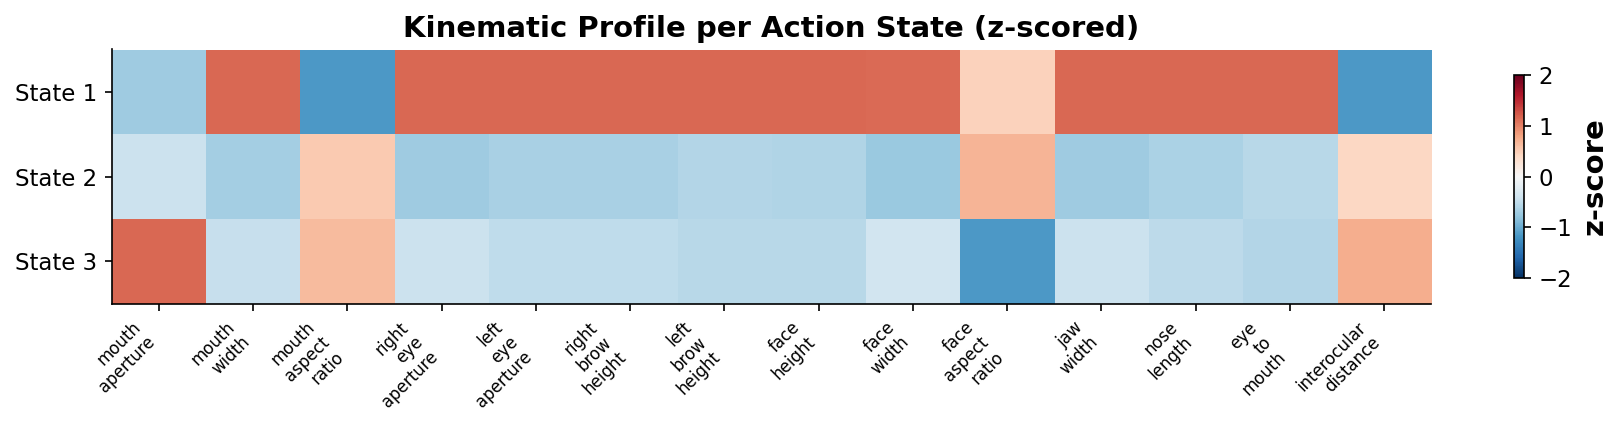


Cluster sizes:
  State 1: 192 frames (67.1%)
  State 2: 55 frames (19.2%)
  State 3: 39 frames (13.6%)


In [10]:
import pandas as pd

# Mean kinematic profile per cluster
ts_analysis = ts[feature_cols].copy()
ts_analysis["cluster"] = frame_labels

cluster_means = ts_analysis.groupby("cluster").mean()
# Drop cluster 0 (unassigned) if it exists
cluster_means = cluster_means[cluster_means.index > 0]

# Z-score the cluster means for visualization
cluster_z = (cluster_means - cluster_means.mean()) / (cluster_means.std() + 1e-8)

fig, ax = plt.subplots(figsize=(12, max(3, n_clusters * 0.4)))
im = ax.imshow(cluster_z.values, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)
ax.set_yticks(range(len(cluster_z)))
ax.set_yticklabels([f"State {i}" for i in cluster_z.index])
ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels([c.replace("_", "\n") for c in feature_cols], rotation=45, ha="right", fontsize=8)
ax.set_title("Kinematic Profile per Action State (z-scored)")
plt.colorbar(im, ax=ax, shrink=0.8, label="z-score")
plt.tight_layout()
save_fig(fig, "cluster_profiles", str(OUTPUT_DIR))
plt.show()

# Print cluster sizes
print("\nCluster sizes:")
for c in sorted(ts_analysis["cluster"].unique()):
    if c > 0:
        count = (frame_labels == c).sum()
        pct = count / n_frames * 100
        print(f"  State {c}: {count} frames ({pct:.1f}%)")

## 11. Transition Matrix

Which facial actions tend to follow which? This reveals temporal structure in facial behavior.

Figure saved: A:\NonEnclosureProjects\inprep\PrimateFace\primateface_oss\PrimateFace_os\demos\notebooks\action_discovery_output\transition_matrix (.png/.svg/.pdf)


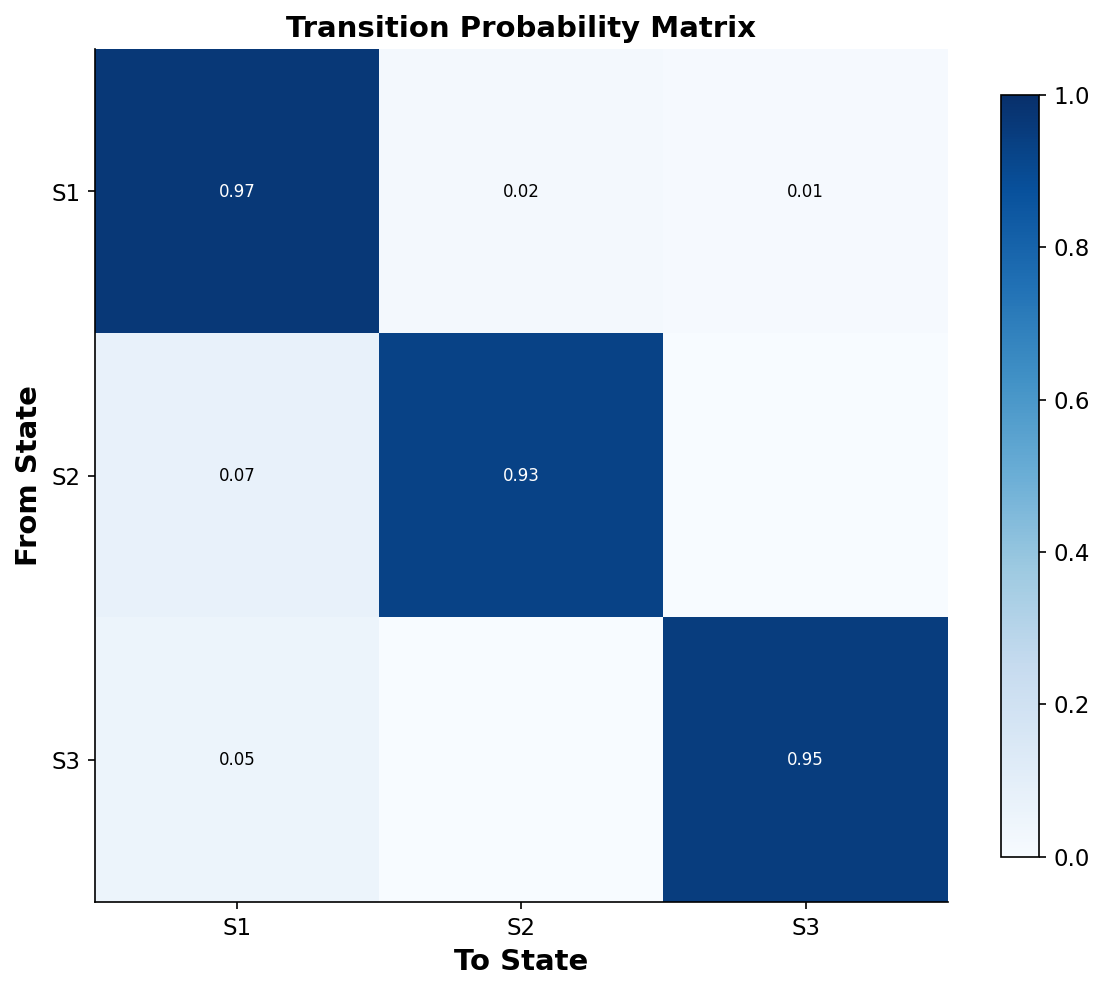

In [11]:
# Compute transition matrix
unique_states = sorted([s for s in np.unique(frame_labels) if s > 0])
n_states = len(unique_states)
state_map = {s: i for i, s in enumerate(unique_states)}

trans = np.zeros((n_states, n_states))
for t in range(len(frame_labels) - 1):
    s1, s2 = frame_labels[t], frame_labels[t + 1]
    if s1 > 0 and s2 > 0:
        trans[state_map[s1], state_map[s2]] += 1

# Normalize rows
row_sums = trans.sum(axis=1, keepdims=True)
trans_prob = np.divide(trans, row_sums, where=row_sums > 0, out=np.zeros_like(trans))

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(trans_prob, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(n_states))
ax.set_yticks(range(n_states))
ax.set_xticklabels([f"S{s}" for s in unique_states])
ax.set_yticklabels([f"S{s}" for s in unique_states])
ax.set_xlabel("To State")
ax.set_ylabel("From State")
ax.set_title("Transition Probability Matrix")

# Annotate cells
for i in range(n_states):
    for j in range(n_states):
        val = trans_prob[i, j]
        if val > 0.01:
            color = "white" if val > 0.5 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=color)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
save_fig(fig, "transition_matrix", str(OUTPUT_DIR))
plt.show()

## Summary

This notebook demonstrated **unsupervised discovery of facial actions** using PrimateFace landmarks + a MotionMapper-inspired pipeline:

1. **Kinematic features** capture facial geometry over time
2. **PCA + wavelets** encode temporal dynamics at multiple timescales
3. **UMAP + watershed** segment the behavioral space into discrete states
4. **Ethogram + transition matrix** reveal temporal structure

The discovered states can represent lip smacks, blinks, mouth openings, neutral expressions, and other recurring facial actions — all without any manual annotation.

### Next Steps
- Compare discovered actions across individuals or species
- Correlate with audio (see [Howler Vocal-Motor Coupling](howler_vocal_motor_coupling.ipynb))
- Use discovered states as labels for supervised classification

### See Also
- [Quick Start](quickstart.ipynb) — PrimateFace API basics
- [Howler Vocal-Motor Coupling](howler_vocal_motor_coupling.ipynb) — audio-face correlation
- [Landmark Demographics](landmark_demographics.ipynb) — age/sex from landmarks